# NuAncestor Telescope Visibility: Inclination Comparison

This notebook compares telescope visibility results obtained from three FreeFlyer simulations. Three circular orbits are considered with inclinations 0°, 20°, and 40°.

For each orbit, the night contact windows, elevation tracking speed, and azimuthal tracking speed are compared. The notebook also calculates the mean night contacts/day, equivalent interval between contacts, tracking-speed range, per-telescope visibility statistics, percentage visibility change relative to the i=0° orbit, and invalid night analysis.

Version 07/2026 by Pedro de S. C. Leonardo

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display

In [2]:
# Main folder containing the three simulation folders
BASE = Path("All_Results/Inclination Comparison/365_days")
#BASE = Path("All_Results/Inclination Comparison/30_days")

# Settings to change !!
SEMI_MAJOR_AXIS = 23200  # km
DAYS = 365 # 365 or 30
SAVE_FIGURES = False
SHOW_REQUIREMENTS = False
MAX_ELEVATION_SPEED = 15
MAX_AZIMUTHAL_SPEED = 600

In [3]:
stations = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]
colors = ["r", "blueviolet", "cyan", "orange", "lime"]

# Inclinations are ordered from top to bottom in the plots
cases = [
    {"name": "i = 0°", "inclination": 0, "folder": "Results_a23200_i0"},
    {"name": "i = 20°", "inclination": 20, "folder": "Results_a23200_i20"},
    {"name": "i = 40°", "inclination": 40, "folder": "Results_a23200_i40"}]

# Read one FreeFlyer results file
def read_result(folder, filename):
    path = BASE / folder / filename
    return pd.read_csv(path, skiprows=3, sep=r"\s+").to_numpy(dtype=float)

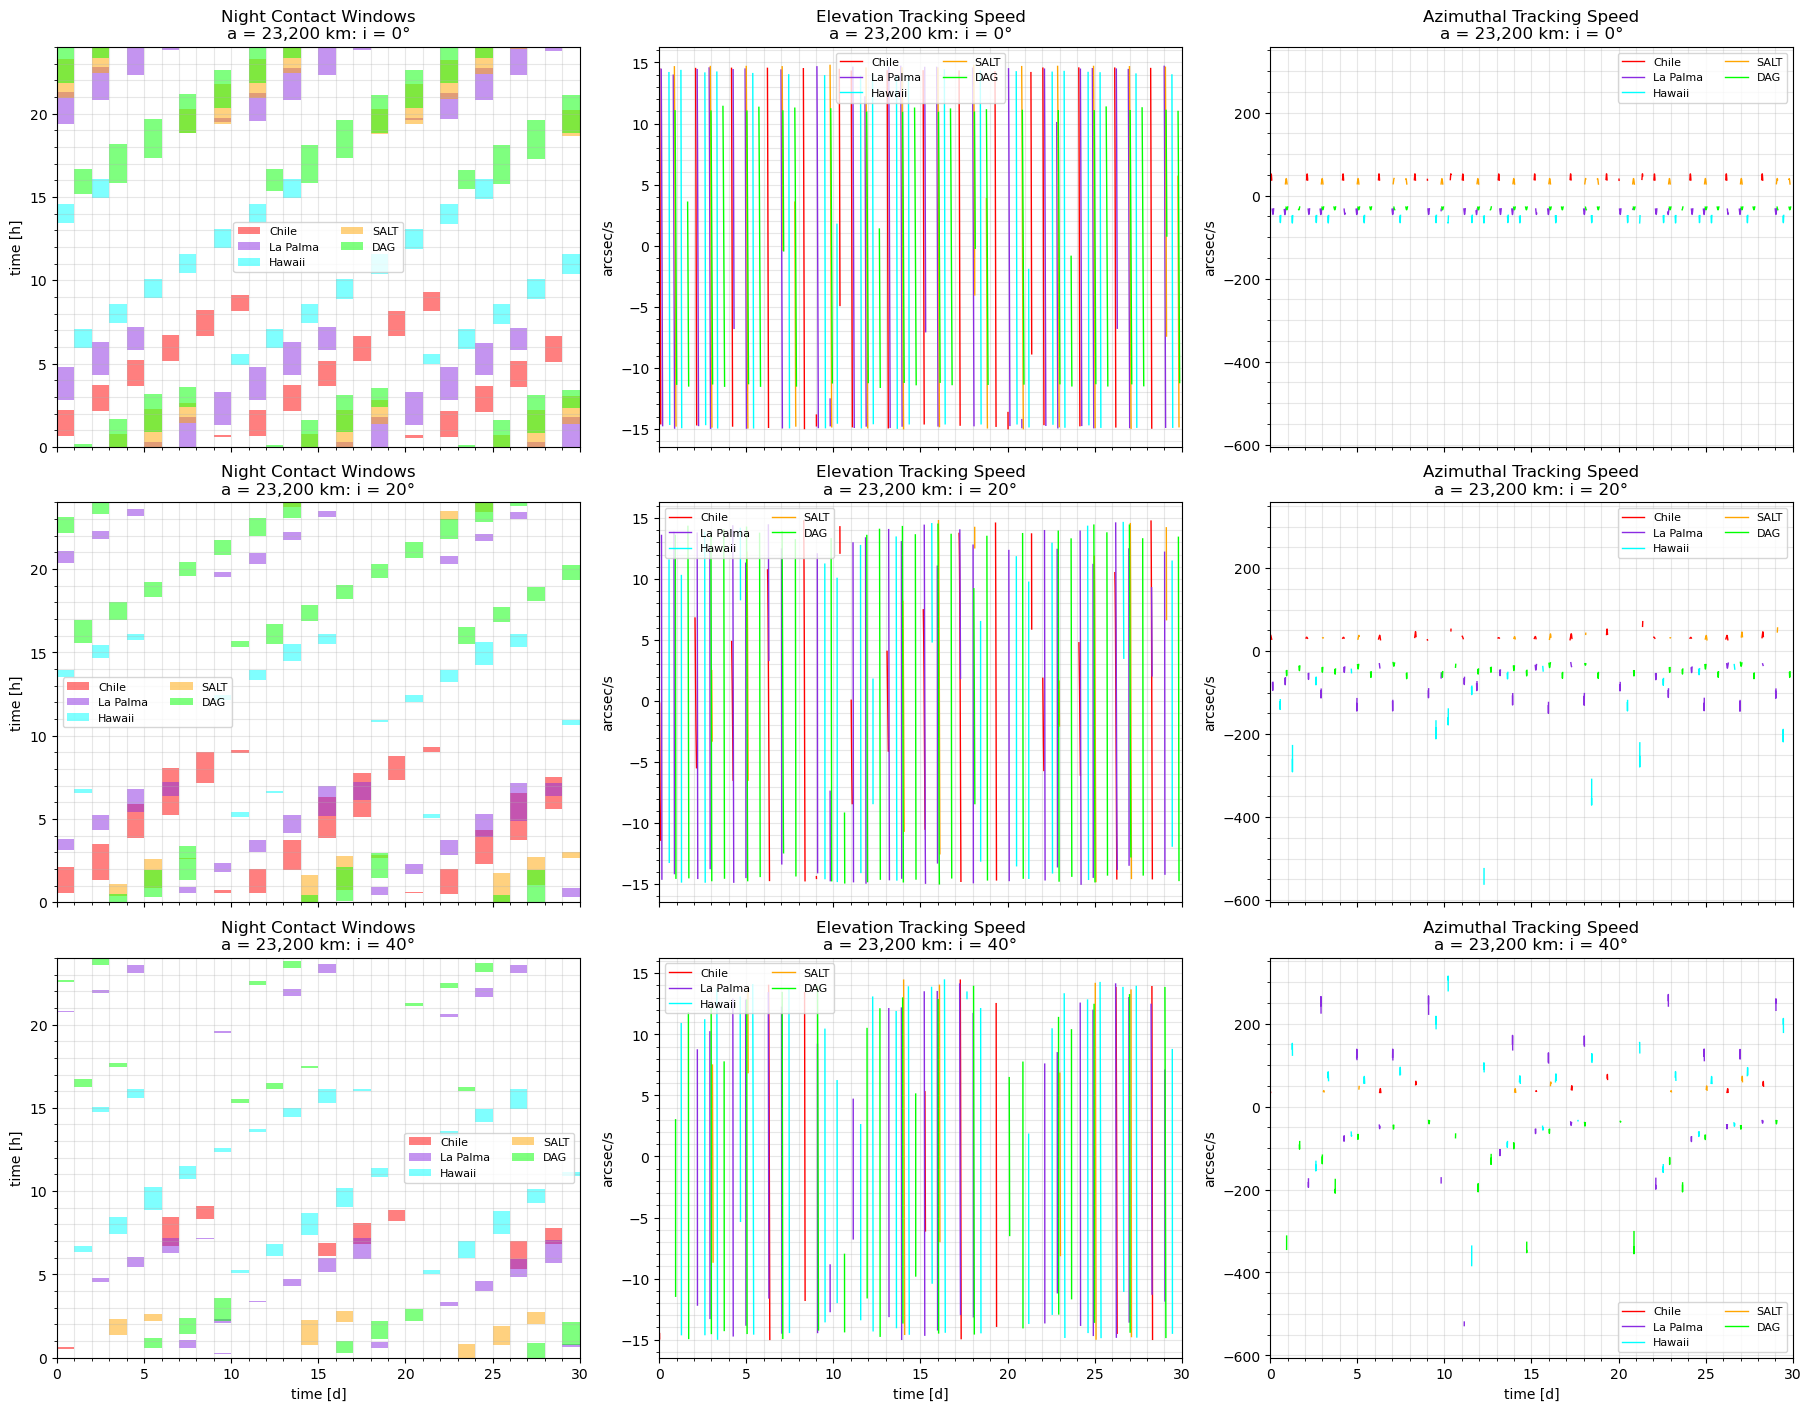

In [11]:
# Days to plot
START_DAY = 0
END_DAY = 30


def plot_contact_windows(ax, folder, title):
    data = read_result(folder, "InContact.txt")
    data = data[
        (data[:, 0] >= START_DAY) &
        (data[:, 0] <= END_DAY)
    ]

    time = data[:, 0]
    day = np.floor(time) + 0.5
    hour = (time - np.floor(time)) * 24
    dt_hours = np.median(np.diff(time)) * 24

    for i, station in enumerate(stations):
        visible = data[:, i + 1] == 1
        ax.bar(
            day[visible],
            np.full(visible.sum(), dt_hours),
            width=1,
            bottom=hour[visible],
            color=colors[i],
            alpha=0.5,
            label=station
        )

    ax.set_title(title)
    ax.set_ylabel("time [h]")
    ax.set_xlim(START_DAY, END_DAY)
    ax.set_ylim(0, 24)
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.3)
    ax.legend(fontsize=8, ncol=2)


def plot_speed(ax, folder, filename, title, requirement=None):
    data = read_result(folder, filename)
    data = data[
        (data[:, 0] >= START_DAY) &
        (data[:, 0] <= END_DAY)
    ]

    time = data[:, 0]
    values = data[:, 1:].copy()

    # Ignore zeros outside contact windows
    values[values == 0] = np.nan

    for i, station in enumerate(stations):
        ax.plot(
            time,
            values[:, i],
            color=colors[i],
            linewidth=1,
            label=station
        )

    # Optional telescope requirement
    if SHOW_REQUIREMENTS and requirement is not None:
        ax.axhline(
            requirement,
            color="black",
            linestyle="--",
            linewidth=1.2,
            label=f"Requirement: {requirement:g} arcsec/s"
        )

    ax.set_title(title)
    ax.set_ylabel("arcsec/s")
    ax.set_xlim(START_DAY, END_DAY)
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.3)
    ax.legend(fontsize=8, ncol=2)


fig, axes = plt.subplots(
    3, 3,
    figsize=(18, 14),
    sharex="col",
    sharey="col",
    constrained_layout=True
)

for row, case in enumerate(cases):
    subtitle = f"a = {SEMI_MAJOR_AXIS:,} km: {case['name']}"

    plot_contact_windows(
        axes[row, 0],
        case["folder"],
        f"Night Contact Windows\n{subtitle}"
    )

    plot_speed(
        axes[row, 1],
        case["folder"],
        "Elevation Speed.txt",
        f"Elevation Tracking Speed\n{subtitle}",
        requirement=MAX_ELEVATION_SPEED
    )

    plot_speed(
        axes[row, 2],
        case["folder"],
        "Azimuthal Speed.txt",
        f"Azimuthal Tracking Speed\n{subtitle}",
        requirement=MAX_AZIMUTHAL_SPEED
    )

for ax in axes[-1, :]:
    ax.set_xlabel("time [d]")

# Change SAVE_FIGURES to True to save the figure
if SAVE_FIGURES:
    output = BASE / "comparison_plots"
    output.mkdir(exist_ok=True)

    fig.savefig(
        output /
        f"inclination_comparison_a{SEMI_MAJOR_AXIS}_days"
        f"{START_DAY}-{END_DAY}.png",
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

In [5]:
MU_EARTH = 398600.4418  # Earth's gravitational parameter [km^3/s^2]


def contact_statistics(folder):
    data = read_result(folder, "InContact.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    time = data[:, 0]
    in_contact = data[:, 1:] == 1

    previous = np.vstack((
        np.zeros((1, in_contact.shape[1]), dtype=bool),
        in_contact[:-1]))
    contact_starts = in_contact & ~previous

    duration_days = time[-1] - time[0]
    contacts_per_day = contact_starts.sum(axis=0) / duration_days
    mean_contacts_per_day = contacts_per_day.mean()

    mean_interval_hours = (
        24 / mean_contacts_per_day
        if mean_contacts_per_day > 0 else np.nan)

    return mean_contacts_per_day, mean_interval_hours


def tracking_speed_range(folder):
    data = read_result(folder, "Tracking Speed.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    maxima = []

    for values in data[:, 1:].T:
        values = np.abs(values[np.isfinite(values) & (values != 0)])

        if values.size:
            maxima.append(values.max())

    return (
        (min(maxima), max(maxima))
        if maxima else (np.nan, np.nan))


def fmt(value, decimals=2):
    return f"{value:.{decimals}f}".rstrip("0").rstrip(".")


period_hours = (
    2 * np.pi * np.sqrt(SEMI_MAJOR_AXIS**3 / MU_EARTH) / 3600)
columns = {}

for case in cases:
    contacts_per_day, interval_hours = contact_statistics(case["folder"])
    speed_min, speed_max = tracking_speed_range(case["folder"])

    columns[case["name"]] = [
        f"{SEMI_MAJOR_AXIS:,} km",
        f"{period_hours:.3f} h",
        f"{case['inclination']}°",
        f"{contacts_per_day:.3f}",
        f"{interval_hours:.2f} h",
        f"{fmt(speed_min)} – {fmt(speed_max)} arcsec/s"]


summary = pd.DataFrame(columns, index=[
    "Semi-major axis",
    "Orbit period",
    "Orbit inclination",
    "Mean night contacts/day per telescope",
    "Equivalent mean interval between night contacts",
    "Max. tracking speed for different latitudes"])

summary.index.name = "Orbit"

table_styles = [
    {"selector": "th", "props": [
        ("text-align", "center"),
        ("font-weight", "bold"),
        ("border", "1px solid black")]},
    {"selector": "td", "props": [
        ("text-align", "center"),
        ("border", "1px solid black")]}]

display(summary.style.set_table_styles(table_styles))

,i = 0°,i = 20°,i = 40°
Orbit,,,
Semi-major axis,"23,200 km","23,200 km","23,200 km"
Orbit period,9.769 h,9.769 h,9.769 h
Orbit inclination,0°,20°,40°
Mean night contacts/day per telescope,0.718,0.599,0.524
Equivalent mean interval between night contacts,33.43 h,40.04 h,45.77 h
Max. tracking speed for different latitudes,27.01 – 29.25 arcsec/s,30.4 – 31.72 arcsec/s,35.63 – 37.01 arcsec/s


In [6]:
# Telescopes to include in the statistics
SELECTED_TELESCOPES = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]


def contact_intervals(time, visible):
    """Return the start and end time of every continuous contact window."""
    dt = np.median(np.diff(time))
    end_of_data = time[-1] + dt

    # Detect transitions into and out of contact
    changes = np.diff(visible.astype(int))
    starts = list(time[1:][changes == 1])
    ends = list(time[1:][changes == -1])

    # Include contacts active at the start or end
    if visible[0]:
        starts.insert(0, time[0])
    if visible[-1]:
        ends.append(end_of_data)

    return np.array(starts), np.array(ends), end_of_data


def visibility_statistics(time, visible):
    starts, ends, end_of_data = contact_intervals(time, visible)
    durations = (ends - starts) * 24

    if durations.size:
        median_duration = np.median(durations)
        maximum_duration = np.max(durations)
        total_contact = np.sum(durations)
    else:
        median_duration = np.nan
        maximum_duration = np.nan
        total_contact = 0.0

    # Include gaps at the beginning and end
    if starts.size:
        gaps = [starts[0] - time[0]]
        gaps.extend(starts[1:] - ends[:-1])
        gaps.append(end_of_data - ends[-1])
        maximum_gap = np.max(gaps) * 24
    else:
        maximum_gap = (end_of_data - time[0]) * 24

    return {
        "total_contact_h": total_contact,
        "median_duration_h": median_duration,
        "maximum_duration_h": maximum_duration,
        "maximum_gap_h": maximum_gap}


case_by_inclination = {
    case["inclination"]: case for case in cases}

baseline = read_result(
    case_by_inclination[0]["folder"], "InContact.txt")
baseline = baseline[
    (baseline[:, 0] >= 0) & (baseline[:, 0] <= DAYS)]

rows = []

for inclination in [20, 40]:
    compared = read_result(
        case_by_inclination[inclination]["folder"], "InContact.txt")
    compared = compared[
        (compared[:, 0] >= 0) & (compared[:, 0] <= DAYS)]

    if baseline.shape != compared.shape or not np.allclose(
        baseline[:, 0], compared[:, 0]):
        raise ValueError(
            f"Time grids do not match for i = 0° and i = {inclination}°.")

    time = baseline[:, 0]

    for station in SELECTED_TELESCOPES:
        i = stations.index(station)

        baseline_visible = baseline[:, i + 1] == 1
        compared_visible = compared[:, i + 1] == 1

        baseline_stats = visibility_statistics(
            time, baseline_visible)
        compared_stats = visibility_statistics(
            time, compared_visible)

        difference_hours = (
            compared_stats["total_contact_h"]
            - baseline_stats["total_contact_h"])

        change_percent = (
            100 * difference_hours / baseline_stats["total_contact_h"]
            if baseline_stats["total_contact_h"] > 0 else np.nan)

        rows.append({
            "Inclination [deg]": inclination,
            "Telescope": station,
            "i = 0 total contact [h]":
                baseline_stats["total_contact_h"],
            "Compared total contact [h]":
                compared_stats["total_contact_h"],
            "Difference from i = 0 [h]": difference_hours,
            "Visibility change from i = 0 [%]": change_percent,
            "i = 0 median duration [h]":
                baseline_stats["median_duration_h"],
            "Compared median duration [h]":
                compared_stats["median_duration_h"],
            "i = 0 maximum duration [h]":
                baseline_stats["maximum_duration_h"],
            "Compared maximum duration [h]":
                compared_stats["maximum_duration_h"],
            "i = 0 maximum gap [h]":
                baseline_stats["maximum_gap_h"],
            "Compared maximum gap [h]":
                compared_stats["maximum_gap_h"]})


contact_stats = pd.DataFrame(rows).round(2)
display(contact_stats)

,Inclination [deg],Telescope,i = 0 total contact [h],Compared total contact [h],Difference from i = 0 [h],Visibility change from i = 0 [%],i = 0 median duration [h],Compared median duration [h],i = 0 maximum duration [h],Compared maximum duration [h],i = 0 maximum gap [h],Compared maximum gap [h]
0,20,Chile,348.93,284.93,-64.00,-18.34,1.57,0.87,1.60,2.80,47.97,49.17
1,20,La Palma,434.17,237.80,-196.37,-45.23,1.97,0.83,2.00,2.53,47.57,148.10
2,20,Hawaii,260.43,255.97,-4.47,-1.72,1.17,0.83,1.17,3.17,48.37,164.80
3,20,SALT,515.90,221.90,-294.00,-56.99,2.33,0.93,2.37,2.40,47.20,212.97
4,20,DAG,489.57,224.40,-265.17,-54.16,2.30,1.07,2.33,2.13,65.50,941.83
5,40,Chile,348.93,123.47,-225.47,-64.62,1.57,0.58,1.60,1.73,47.97,213.67
6,40,La Palma,434.17,114.20,-319.97,-73.70,1.97,0.47,2.00,1.63,47.57,262.50
7,40,Hawaii,260.43,155.40,-105.03,-40.33,1.17,0.53,1.17,1.83,48.37,164.33
8,40,SALT,515.90,104.27,-411.63,-79.79,2.33,0.40,2.37,1.60,47.20,263.20
9,40,DAG,489.57,100.97,-388.60,-79.38,2.30,0.53,2.33,1.43,65.50,1109.07


#### Contact statistics:

- i = 0 total contact [h]: Total usable contact time for the baseline orbit.
- Compared total contact [h]: Total usable contact time for the inclined orbit.
- Difference from i = 0 [h]: Absolute contact-time change relative to i=0. Positive values indicate more contact and negative values indicate less.
- Visibility change from i = 0 [%]: Percentage change in total contact relative to the baseline orbit.
- Median duration [h]: Median duration of an individual continuous contact window.
- Maximum duration [h]: Duration of the longest continuous contact window.
- Maximum gap [h]: Longest continuous period without contact, including gaps at the beginning and end of the analysis.

In [7]:
orbit_rows = []

for case in cases:
    data = read_result(case["folder"], "InContact.txt")
    data = data[
        (data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    time = data[:, 0]

    for station in SELECTED_TELESCOPES:
        i = stations.index(station)
        visible = data[:, i + 1] == 1

        stats = visibility_statistics(time, visible)

        orbit_rows.append({
            "Inclination [deg]": case["inclination"],
            "Telescope": station,
            "Total contact [h]": stats["total_contact_h"],
            "Median duration [h]": stats["median_duration_h"],
            "Maximum duration [h]": stats["maximum_duration_h"],
            "Maximum gap [h]": stats["maximum_gap_h"]})


orbit_stats = pd.DataFrame(orbit_rows)

summary_stats = (
    orbit_stats
    .groupby("Inclination [deg]", as_index=False)
    .mean(numeric_only=True)
    .rename(columns={
        "Total contact [h]": "Mean total contact [h]",
        "Median duration [h]": "Mean median duration [h]",
        "Maximum duration [h]": "Mean maximum duration [h]",
        "Maximum gap [h]": "Mean maximum gap [h]"})
    .round(2))

display(summary_stats)

,Inclination [deg],Mean total contact [h],Mean median duration [h],Mean maximum duration [h],Mean maximum gap [h]
0,0,409.80,1.87,1.89,51.32
1,20,245.00,0.91,2.61,303.37
2,40,119.66,0.50,1.65,402.55


In [8]:
def visibility_label(percent, hours):
    if pd.isna(percent):
        return "Undefined"
    if percent > 0:
        return f"+{percent:.2f}% (+{hours:.2f} h)"
    if percent < 0:
        return f"-{abs(percent):.2f}% (-{abs(hours):.2f} h)"
    return "No change"


visibility_percent = (
    contact_stats
    .pivot(
        index="Telescope",
        columns="Inclination [deg]",
        values="Visibility change from i = 0 [%]")
    .reindex(SELECTED_TELESCOPES))

visibility_hours = (
    contact_stats
    .pivot(
        index="Telescope",
        columns="Inclination [deg]",
        values="Difference from i = 0 [h]")
    .reindex(SELECTED_TELESCOPES))

visibility_comparison = pd.DataFrame(
    index=SELECTED_TELESCOPES)

for inclination in visibility_percent.columns:
    visibility_comparison[
        f"i = {inclination}° compared with i = 0°"] = [
            visibility_label(percent, hours)
            for percent, hours in zip(
                visibility_percent[inclination],
                visibility_hours[inclination])]

visibility_comparison.index.name = "Telescope"
display(visibility_comparison)

,i = 20° compared with i = 0°,i = 40° compared with i = 0°
Telescope,,
Chile,-18.34% (-64.00 h),-64.62% (-225.47 h)
La Palma,-45.23% (-196.37 h),-73.70% (-319.97 h)
Hawaii,-1.72% (-4.47 h),-40.33% (-105.03 h)
SALT,-56.99% (-294.00 h),-79.79% (-411.63 h)
DAG,-54.16% (-265.17 h),-79.38% (-388.60 h)


In [9]:
# Contact requirement settings
MIN_VALID_CONTACT_H = 0.5  # 30 minutes
MAX_CONSECUTIVE_MISSED_NIGHTS = 2
REQUIREMENT_TELESCOPES = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]
EXCLUDE_PARTIAL_EDGE_NIGHTS = True # If true, a nighttime interval already underway when the simulation begins, 
                                   # or unfinished when it ends, is excluded. 
                                   # This prevents a partial night from being incorrectly classified as missed.


def infer_simulation_end(time):
    """Infer the simulation end time from the output samples."""
    if len(time) < 2:
        raise ValueError("At least two output time samples are required.")

    time_steps = np.diff(time)

    if not np.all(time_steps > 0):
        raise ValueError("Output times must be strictly increasing.")

    dt = np.median(time_steps)

    return time[-1] + dt


def get_boolean_intervals(time, state, simulation_end):
    """Return the start and end times of each continuous True interval."""
    state = np.asarray(state, dtype=bool)

    if len(time) != len(state):
        raise ValueError("Time and Boolean state arrays must have equal lengths.")

    padded = np.r_[False, state, False]
    start_indices = np.where(np.diff(padded.astype(int)) == 1)[0]
    end_indices = np.where(np.diff(padded.astype(int)) == -1)[0]

    interval_starts = time[start_indices]
    interval_ends = np.array([time[index] if index < len(time) else simulation_end
                              for index in end_indices])

    return interval_starts, interval_ends


def get_night_intervals(time, is_night, simulation_end):
    """
    Return the continuous nighttime intervals for one telescope.

    When EXCLUDE_PARTIAL_EDGE_NIGHTS is True, a night already underway
    at the start of the simulation or unfinished at the end is excluded.
    """
    night_starts, night_ends = get_boolean_intervals(
        time, is_night, simulation_end)

    keep = np.ones(len(night_starts), dtype=bool)

    if EXCLUDE_PARTIAL_EDGE_NIGHTS and len(night_starts) > 0:
        if is_night[0]:
            keep[0] = False
        if is_night[-1]:
            keep[-1] = False

    return night_starts[keep], night_ends[keep]


def get_missed_night_runs(night_has_valid_contact):
    """Return inclusive ranges of consecutive nights without valid contact."""
    runs = []
    run_start = None

    for night_index, has_contact in enumerate(night_has_valid_contact):
        if not has_contact and run_start is None:
            run_start = night_index
        elif has_contact and run_start is not None:
            runs.append((run_start, night_index - 1))
            run_start = None

    if run_start is not None:
        runs.append((run_start, len(night_has_valid_contact) - 1))

    return runs


def evaluate_telescope_requirements(time, visible, is_night, simulation_end):
    """
    Evaluate both requirements for one telescope.

    Requirement 1:
        A continuous contact within a nighttime interval must last at
        least 30 minutes.

    Requirement 2:
        At most two consecutive nights may have no valid contact.
        In longer streaks, nights from the third missed night onward
        are counted as cadence-invalid.
    """
    night_starts, night_ends = get_night_intervals(
        time, is_night, simulation_end)

    if len(night_starts) == 0:
        raise ValueError("No complete nighttime intervals were found.")

    contact_starts, contact_ends = get_boolean_intervals(
        time, visible, simulation_end)

    night_has_valid_contact = np.zeros(len(night_starts), dtype=bool)
    valid_contact_count = 0

    for night_index, (night_start, night_end) in enumerate(
        zip(night_starts, night_ends)):

        overlap_starts = np.maximum(contact_starts, night_start)
        overlap_ends = np.minimum(contact_ends, night_end)
        overlap_durations_h = np.maximum(0, overlap_ends - overlap_starts) * 24
        valid_contacts = overlap_durations_h >= MIN_VALID_CONTACT_H - 1e-9

        night_has_valid_contact[night_index] = np.any(valid_contacts)
        valid_contact_count += int(valid_contacts.sum())

    missed_runs = get_missed_night_runs(night_has_valid_contact)

    longest_missed_streak = max(
        (end - start + 1 for start, end in missed_runs), default=0)

    invalid_nights = sum(
        max(0, end - start + 1 - MAX_CONSECUTIVE_MISSED_NIGHTS)
        for start, end in missed_runs)

    violating_streaks = [
        f"Nights {start + 1}–{end + 1}"
        for start, end in missed_runs
        if end - start + 1 > MAX_CONSECUTIVE_MISSED_NIGHTS]

    return {"Analysed nights": len(night_starts),
            "Valid contacts [≥30 min]": valid_contact_count,
            "Nights with valid contact": int(night_has_valid_contact.sum()),
            "Missed nights": int((~night_has_valid_contact).sum()),
            "Invalid nights": invalid_nights,
            "Longest missed streak [nights]": longest_missed_streak,
            "Cadence requirement satisfied": "Yes" if invalid_nights == 0 else "No",
            "Violating streaks": ", ".join(violating_streaks)
            if violating_streaks else "None"}


def create_inclination_requirement_table(case):
    """Create one telescope requirement table for one inclination."""
    rows = []

    folder = case["folder"]
    contact_data = read_result(folder, "InContact.txt")
    night_data = read_result(folder, "IsNight.txt")

    # Limit both files to the selected simulation duration
    contact_data = contact_data[
        (contact_data[:, 0] >= 0) & (contact_data[:, 0] < DAYS)]
    night_data = night_data[
        (night_data[:, 0] >= 0) & (night_data[:, 0] < DAYS)]

    contact_time = contact_data[:, 0]
    night_time = night_data[:, 0]

    if len(contact_time) != len(night_time):
        raise ValueError(
            f"InContact.txt and IsNight.txt have different lengths in {folder}.")

    if not np.allclose(contact_time, night_time, rtol=0, atol=1e-10):
        raise ValueError(
            f"InContact.txt and IsNight.txt use different time samples in {folder}.")

    simulation_end = min(DAYS, infer_simulation_end(contact_time))

    for telescope in REQUIREMENT_TELESCOPES:
        column = stations.index(telescope) + 1
        visible = contact_data[:, column] >= 0.5
        is_night = night_data[:, column] >= 0.5

        result = evaluate_telescope_requirements(
            contact_time, visible, is_night, simulation_end)

        rows.append({"Inclination [deg]": case["inclination"],
                     "Telescope": telescope,
                     **result})

    return pd.DataFrame(rows)


# Display one table for each inclination
inclination_tables = {}

for case in cases:
    inclination_name = case["name"]
    inclination_table = create_inclination_requirement_table(case)
    inclination_tables[inclination_name] = inclination_table

    print(f"\n{inclination_name} (a = {SEMI_MAJOR_AXIS:.0f} km)")
    display(inclination_table.style.hide(axis="index"))


i = 0° (a = 23200 km)


Inclination [deg],Telescope,Analysed nights,Valid contacts [≥30 min],Nights with valid contact,Missed nights,Invalid nights,Longest missed streak [nights],Cadence requirement satisfied,Violating streaks
0,Chile,365,237,237,128,0,1,Yes,None
0,La Palma,364,239,239,125,0,1,Yes,None
0,Hawaii,365,227,227,138,0,1,Yes,None
0,SALT,364,245,245,119,0,1,Yes,None
0,DAG,364,240,240,124,0,2,Yes,None



i = 20° (a = 23200 km)


Inclination [deg],Telescope,Analysed nights,Valid contacts [≥30 min],Nights with valid contact,Missed nights,Invalid nights,Longest missed streak [nights],Cadence requirement satisfied,Violating streaks
20,Chile,365,168,168,197,21,7,No,"Nights 114–117, Nights 125–128, Nights 135–139, Nights 146–150, Nights 157–163, Nights 168–173, Nights 181–184"
20,La Palma,364,166,166,198,37,6,No,"Nights 7–10, Nights 109–112, Nights 120–123, Nights 129–134, Nights 140–142, Nights 149–153, Nights 160–162, Nights 169–173, Nights 177–182, Nights 188–193, Nights 199–202, Nights 210–213, Nights 303–306, Nights 314–317, Nights 324–328"
20,Hawaii,365,147,147,218,59,8,No,"Nights 4–11, Nights 17–22, Nights 28–31, Nights 39–42, Nights 249–252, Nights 260–263, Nights 271–274, Nights 280–285, Nights 291–296, Nights 300–307, Nights 311–318, Nights 323–329, Nights 334–341, Nights 345–352, Nights 358–361"
20,SALT,364,183,183,181,58,8,No,"Nights 6–13, Nights 17–22, Nights 28–33, Nights 41–44, Nights 268–271, Nights 279–282, Nights 288–293, Nights 299–304, Nights 308–315, Nights 319–323, Nights 328–334, Nights 336–343, Nights 347–354, Nights 358–363"
20,DAG,364,172,172,192,91,47,No,"Nights 88–93, Nights 99–104, Nights 110–115, Nights 119–126, Nights 130–176, Nights 178–187, Nights 189–196, Nights 200–207, Nights 213–218, Nights 224–227, Nights 235–238"



i = 40° (a = 23200 km)


Inclination [deg],Telescope,Analysed nights,Valid contacts [≥30 min],Nights with valid contact,Missed nights,Invalid nights,Longest missed streak [nights],Cadence requirement satisfied,Violating streaks
40,Chile,365,108,108,257,154,8,No,"Nights 1–6, Nights 10–15, Nights 21–26, Nights 30–35, Nights 41–46, Nights 50–55, Nights 61–66, Nights 70–76, Nights 81–86, Nights 90–96, Nights 101–106, Nights 112–116, Nights 122–126, Nights 131–136, Nights 142–147, Nights 151–156, Nights 162–166, Nights 171–176, Nights 182–186, Nights 192–196, Nights 202–206, Nights 212–217, Nights 222–226, Nights 232–237, Nights 242–246, Nights 252–257, Nights 261–268, Nights 272–277, Nights 281–288, Nights 292–297, Nights 301–308, Nights 312–319, Nights 321–325, Nights 327–330, Nights 332–336, Nights 338–345, Nights 349–356, Nights 360–365"
40,La Palma,364,89,89,275,170,14,No,"Nights 1–3, Nights 7–14, Nights 18–23, Nights 29–34, Nights 38–43, Nights 49–54, Nights 58–63, Nights 69–74, Nights 78–83, Nights 89–94, Nights 98–103, Nights 109–114, Nights 118–123, Nights 129–136, Nights 138–147, Nights 149–162, Nights 164–173, Nights 175–182, Nights 186–193, Nights 197–202, Nights 208–213, Nights 217–222, Nights 228–233, Nights 237–242, Nights 248–253, Nights 257–262, Nights 268–273, Nights 277–282, Nights 288–293, Nights 299–304, Nights 308–314, Nights 319–325, Nights 327–333, Nights 336–342, Nights 347–353, Nights 357–362"
40,Hawaii,365,123,123,242,132,8,No,"Nights 1–3, Nights 9–12, Nights 18–23, Nights 29–33, Nights 40–44, Nights 49–53, Nights 60–64, Nights 69–73, Nights 80–84, Nights 88–95, Nights 99–104, Nights 108–115, Nights 119–124, Nights 128–135, Nights 139–146, Nights 148–152, Nights 154–157, Nights 159–161, Nights 165–172, Nights 176–181, Nights 187–192, Nights 196–203, Nights 207–212, Nights 216–223, Nights 227–231, Nights 236–242, Nights 247–251, Nights 258–262, Nights 267–271, Nights 277–282, Nights 288–291, Nights 299–302, Nights 308–311, Nights 319–322, Nights 328–333, Nights 339–342, Nights 348–351, Nights 359–362"
40,SALT,364,85,85,279,158,14,No,"Nights 4–13, Nights 17–22, Nights 28–33, Nights 37–42, Nights 48–53, Nights 59–62, Nights 68–73, Nights 79–82, Nights 88–93, Nights 99–102, Nights 108–113, Nights 117–124, Nights 128–133, Nights 139–144, Nights 148–157, Nights 159–162, Nights 166–173, Nights 177–182, Nights 188–193, Nights 197–202, Nights 208–213, Nights 217–224, Nights 228–233, Nights 239–242, Nights 248–253, Nights 259–262, Nights 268–273, Nights 279–282, Nights 288–293, Nights 299–304, Nights 308–315, Nights 319–332, Nights 334–343, Nights 345–352, Nights 356–363"
40,DAG,364,87,87,277,155,45,No,"Nights 1–4, Nights 10–15, Nights 21–24, Nights 30–35, Nights 41–44, Nights 50–55, Nights 61–64, Nights 70–75, Nights 81–84, Nights 90–95, Nights 101–104, Nights 110–115, Nights 121–128, Nights 130–139, Nights 141–185, Nights 187–196, Nights 198–205, Nights 211–216, Nights 220–225, Nights 231–236, Nights 242–245, Nights 251–256, Nights 260–265, Nights 271–276, Nights 282–285, Nights 291–296, Nights 302–305, Nights 311–316, Nights 331–334, Nights 338–340, Nights 349–354, Nights 360–364"


In [10]:
# Summary table: invalid nights per telescope for each inclination
summary_rows = []

for case in cases:
    inclination_name = case["name"]
    inclination_table = inclination_tables[inclination_name]

    row = {"Inclination [deg]": case["inclination"]}

    for telescope in REQUIREMENT_TELESCOPES:
        telescope_data = inclination_table[
            inclination_table["Telescope"] == telescope]

        row[telescope] = int(telescope_data["Invalid nights"].sum())

    row["Total invalid nights"] = sum(
        row[telescope] for telescope in REQUIREMENT_TELESCOPES)

    summary_rows.append(row)

invalid_nights_summary = pd.DataFrame(summary_rows)

display(invalid_nights_summary.style.hide(axis="index"))

Inclination [deg],Chile,La Palma,Hawaii,SALT,DAG,Total invalid nights
0,0,0,0,0,0,0
20,21,37,59,58,91,266
40,154,170,132,158,155,769
